# <b><span style='color: #196f3d '>| PlantTraits2024:</span> Image Only Model [Inference]</b> 
The task is to predict the mean value of 6 plant features based on plant images and tabular data. Training data contains both the mean value and std of plant traits. We will refer to predicting the mean as the main task and predicting the std as the auxillary task. We use an ensemble model of a pretrained vision transformer trained on the images to predict the mean values (main task) and a `Dense` layer model trained on the tabular data to predict the standard deviations (auxillary task).

This notebook is based on [this notebook](https://www.kaggle.com/code/hdjojo/modified-planttraits2024-eda-training) and [this notebook](https://www.kaggle.com/code/mohammedessam97/planttraits2024-pytorch-starter-notebook). The layout is from [Moths WaveNet Starter](https://www.kaggle.com/code/alejopaullier/hms-wavenet-pytorch-train). This notebook is used for inference, the training notebook can be found [here](https://www.kaggle.com/code/jasperpieterse/planttraits2024-image-only-train).

### <b><span style='color: #196f3d '>Table of Contents</span></b> <a class='anchor' id='top'></a>
<div style=" background-color: #ecf0f1 ; padding: 13px 13px; border-radius: 8px; color: white">
<li><a href="#import_libraries">Import Libraries</a></li>
<li><a href="#Configuration">Configuration</a></li>
<li><a href="#load_data">Load Data</a></li>
<li><a href="#outlier_removal">Outlier Removal</a></li>
<li><a href="#crossvalidation">Cross Validation</a></li>    
<li><a href="#augmentations">Augmentations</a></li>
<li><a href="#dataset">Dataset</a></li>
<li><a href="#dataloader">DataLoader</a></li>
<li><a href="#model">Model</a></li>
<li><a href="#inference">Inference</a></li>
<li><a href="#submission">Submission</a></li>
    
</div>

# <b><span style='color: #196f3d '>|</span> Import Libraries</b><a class='anchor' id='import_libraries'></a> [↑](#top) 

***

Import and install all the required libraries for this notebook.

In [1]:
import os
import cv2
import torch
import glob
import time
import joblib
import torchmetrics
import timm
import warnings
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
import pytorch_lightning as pl
import albumentations as A
import imageio.v3 as imageio
import psutil

from glob import glob
from PIL import Image
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from albumentations.pytorch import ToTensorV2
from torchmetrics.regression import R2Score
from sklearn.preprocessing import StandardScaler
from torch.optim.lr_scheduler import OneCycleLR
from torchvision.models import efficientnet
from sklearn.model_selection import StratifiedKFold

tqdm.pandas()

# <b><span style='color: #196f3d '>|</span> Configuration</b><a class='anchor' id='configuration'></a> [↑](#top) 

***

In [2]:
class CFG:
    IMAGE_SIZE = 384
#     BACKBONE = 'efficientnet_b0'      # Name of pretrained EfficientNet model (B0 - B7)
    BACKBONE = 'swin_large_patch4_window12_384.ms_in22k_ft_in1k'
    N_EPOCHS = 6 
    BATCH_SIZE = 10 
    LR_MAX = 1e-4
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.2
    NUM_CLASSES = 6 
    NUM_FOLDS = 5 
    FOLD = 0 # Which fold to set as validation set
    TARGET_COLUMNS = ['X4_mean', 'X11_mean', 'X18_mean', 'X50_mean', 'X26_mean', 'X3112_mean'] #don't change order 
    AUX_TARGET_COLUMNS = ['X4_sd', 'X11_sd', 'X18_sd', 'X50_sd', 'X26_sd', 'X3112_sd']
    SEED = 42  
    CREATE_DATAFRAME = False #Whether to create the data or load it
    USE_SUBSET_DATA = False #Use 1/3th of the data for faster experimentation
    CNN_FEATURES = 64 #Amount of features the CNN should output to the heads
    TABULAR_FEATURES = 32 #Amount of features the Dense layer should output to the heads

# Set a seed using Pytorch Lightning
pl.seed_everything(CFG.SEED, workers=True)
# warnings.filterwarnings('ignore')

# Set base path
BASE_PATH = "/kaggle/input/planttraits2024"
DATAFRAME_PATH = "/kaggle/input/planttraits2024-dataframes"
REDUCED_DATAFRAME_PATH = '/kaggle/input/planttraits2024-reduced-dataset'
BEST_MODEL_PATH = '/kaggle/input/final-tests/R2_logscaled_normalized'

# <b><span style='color: #196f3d '>|</span> Load Data</b><a class='anchor' id='load_data'></a> [↑](#top) 

In [3]:
df = pd.read_csv(f'{BASE_PATH}/train.csv')

if CFG.USE_SUBSET_DATA:
    #SPLIT DATA IN 3 STRATIFIED FOLDS 
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) #split data in 10 Stratified Folds
    # Create separate bin for each trait
    for i, trait in enumerate(CFG.TARGET_COLUMNS):
        bin_edges = np.percentile(df[trait], np.linspace(0, 100, CFG.NUM_FOLDS + 1))
        df[f"bin_{i}"] = np.digitize(df[trait], bin_edges)
    df["final_bin"] = df[[f"bin_{i}" for i in range(len(CFG.TARGET_COLUMNS))]].astype(str).agg("".join, axis=1)

    # Perform the stratified split using final bin
    df = df.reset_index(drop=True)
    for fold, (train_idx, valid_idx) in enumerate(skf.split(df, df["final_bin"])):
        df.loc[valid_idx, "fold"] = fold

    #SELECT ONE FOLD
    df = df[df.fold == CFG.FOLD]
    
    # Drop the bin columns from the dataframe
    bin_columns = [f"bin_{i}" for i in range(len(CFG.TARGET_COLUMNS))]
    df = df.drop(columns= bin_columns +['final_bin','fold'])
    
if CFG.CREATE_DATAFRAME:
    df['image_path'] = df['id'].apply(lambda s: f'{BASE_PATH}/train_images/{s}.jpeg')     # add image path info to df
    df['image_bytes'] = df['image_path'].progress_apply(lambda fp: open(fp, 'rb').read()) # embedd image information in dataframe
    df.loc[:, CFG.AUX_TARGET_COLUMNS] = df.loc[:, CFG.AUX_TARGET_COLUMNS].fillna(-1)      # replace std NaN values with -1 (stds are always >0)
    df.to_pickle('df.pkl')

    test_df = pd.read_csv(f'{BASE_PATH}/test.csv')
    test_df['image_path'] = test_df['id'].apply(lambda s: f'{BASE_PATH}/test_images/{s}.jpeg') 
    test_df['image_bytes'] = test_df['image_path'].progress_apply(lambda fp: open(fp, 'rb').read()) 
    test_df.to_pickle('test_df.pkl')

#load from file, depending on whether we use a subset or full data
else:
    if CFG.USE_SUBSET_DATA:
        df = pd.read_pickle(f'{REDUCED_DATAFRAME_PATH}/df.pkl')
        test_df = pd.read_pickle(f'{REDUCED_DATAFRAME_PATH}/test_df.pkl')
    else:
        df = pd.read_pickle(f'{DATAFRAME_PATH}/df.pkl')
        test_df = pd.read_pickle(f'{DATAFRAME_PATH}/test_df.pkl')
        
#STORE TARGET COLLUMNS
CFG.FEATURE_COLS = test_df.columns[1:-2].tolist() #leave out img-path and image data

# <b><span style='color: #196f3d '>|</span> Outlier Removal</b><a class='anchor' id='outlier_removal'></a> [↑](#top) 

Our training data contains quite some bad outliers. According to the competition host, [these outliers have been removed from the test set](https://www.kaggle.com/competitions/planttraits2024/discussion/483414), however, they remain still in our training and validation dataframe. So before splitting into training and validation, we should remove these outliers.


In [4]:
# REMOVE OUTLIERS FROM MAIN AND TABULAR FEATURES FROM TRAINING DATA
for column in (CFG.TARGET_COLUMNS + CFG.AUX_TARGET_COLUMNS):
    upper_quantile = df[column].quantile(0.985)
    df = df[(df[column] < upper_quantile)]
    df = df[(df[column] > 0) | (df[column] == -1)] # remove negative values except -1

# <b><span style='color: #196f3d '>|</span> Validation</b><a class='anchor' id='crossvalidation'></a> [↑](#top) 

***

We will split the data into `5` stratified folds. It first creates bins based on `6` plant traits distributions and combines them into a final bin column. Then, it uses this bin for balancing similar traits distributions across all folds.


In [5]:
skf = StratifiedKFold(n_splits=CFG.NUM_FOLDS, shuffle=True, random_state=42)

# Create separate bin for each trait
for i, trait in enumerate(CFG.TARGET_COLUMNS):
    bin_edges = np.percentile(df[trait], np.linspace(0, 100, CFG.NUM_FOLDS + 1))
    df[f"bin_{i}"] = np.digitize(df[trait], bin_edges)
df["final_bin"] = df[[f"bin_{i}" for i in range(len(CFG.TARGET_COLUMNS))]].astype(str).agg("".join, axis=1)
df["fold"] = -1  # Initialize fold column

# Perform the stratified split using final bin
df = df.reset_index(drop=True)
for fold, (train_idx, valid_idx) in enumerate(skf.split(df, df["final_bin"])):
    df.loc[valid_idx, "fold"] = fold
    
# Drop the bin columns from the dataframe
bin_columns = [f"bin_{i}" for i in range(len(CFG.TARGET_COLUMNS))]
df = df.drop(columns= bin_columns +['final_bin'])
    
# Create a train and a validation dataframe based on splits
sample_df = df.copy()
train_df = sample_df[sample_df.fold != CFG.FOLD].reset_index(drop=True)
valid_df = sample_df[sample_df.fold == CFG.FOLD].reset_index(drop=True)
train_df.head()

/opt/conda/lib/python3.10/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,id,WORLDCLIM_BIO1_annual_mean_temperature,WORLDCLIM_BIO12_annual_precipitation,WORLDCLIM_BIO13.BIO14_delta_precipitation_of_wettest_and_dryest_month,WORLDCLIM_BIO15_precipitation_seasonality,WORLDCLIM_BIO4_temperature_seasonality,WORLDCLIM_BIO7_temperature_annual_range,SOIL_bdod_0.5cm_mean_0.01_deg,SOIL_bdod_100.200cm_mean_0.01_deg,SOIL_bdod_15.30cm_mean_0.01_deg,...,X3112_mean,X4_sd,X11_sd,X18_sd,X26_sd,X50_sd,X3112_sd,image_path,image_bytes,fold
0,192027691,12.235703,374.466675,62.524445,72.256844,773.592041,33.277779,125,149,136,...,50.216034,0.008921,1.601473,0.025441,0.153608,0.279610,15.045054,/kaggle/input/planttraits2024/train_images/192...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,1
1,195542235,17.270555,90.239998,10.351111,38.220940,859.193298,40.009777,124,144,138,...,574.098472,0.003102,0.258078,0.000866,0.034630,0.010165,11.004477,/kaggle/input/planttraits2024/train_images/195...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,4
2,195728812,18.680834,1473.933350,163.100006,45.009758,381.053986,20.436666,120,131,125,...,1042.686546,0.011692,2.818356,0.110673,0.011334,0.229224,141.857187,/kaggle/input/planttraits2024/train_images/195...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,3
3,195251545,0.673204,530.088867,50.857777,38.230709,1323.526855,45.891998,91,146,120,...,2386.467180,0.006157,1.128000,0.026996,0.553815,0.107092,87.146899,/kaggle/input/planttraits2024/train_images/195...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,2
4,195733955,12.062123,1982.033325,320.138092,74.343796,318.258270,17.557619,101,142,120,...,363.364702,0.002750,0.352804,0.041009,7.854885,0.009494,14.671018,/kaggle/input/planttraits2024/train_images/195...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,1


# <b><span style='color: #196f3d '>|</span> Preprocessing</b><a class='anchor' id='preprocessing'></a> [↑](#top) 
We log-scale the tabular **features**. We then normalize both the **features** and the **targets**. We will use the following notation:
- **(Main) Features:** The images
- **(Main) Targets:** The means of the 6 plant trait features.

Note 1: We cannot log-scale the targets because the R2 metric punishes absolute differences instead of relative differences. Log-scaling the targets thus gives a false R2 score on validation.

Note 2: Although it's essential to apply the same preprocessing steps (like scaling) to both training and validation data to maintain consistency, we fit the scaler on the training data only, to ensure that the statistics (mean and standard deviation) used for scaling are derived exclusively from the data the model sees during the training process.


In [6]:
def apply_log_scale(data_df, columns, log_scale_columns):
    """Log scales the provided columns of the input dataframe if their also in log_scale_columns"""
    data_array = data_df[columns].to_numpy(dtype = np.float32)
    for idx, col in enumerate(columns):
        if col in log_scale_columns:
            # Apply log scale only where values are not -1
            mask = data_array[:, idx] != -1
            data_array[mask, idx] = np.log10(data_array[mask, idx])
    return data_array

# DEFINE LABELS TO LOG SALE
LOG_LABELS = ['X4_mean', 'X11_mean', 'X18_mean', 'X50_mean', 'X26_mean', 'X3112_mean']
LOG_AUX_LABELS = []

# APPLY TO TRAINING AND VALIDATION DATA
train_targets = apply_log_scale(train_df, CFG.TARGET_COLUMNS, LOG_LABELS)
valid_targets = apply_log_scale(valid_df, CFG.TARGET_COLUMNS, LOG_LABELS)

In [7]:
#STORE MAIN FEATURES [NORMALIZATION OF MAIN FEATURES IS HANDLED BY DATALOADER]
train_features = train_df['image_bytes'].values
valid_features = valid_df['image_bytes'].values
test_features  = test_df['image_bytes'].values

# STORE AND NORMALIZE MAIN TARGETS
TARGET_SCALER = StandardScaler()
# train_targets = TARGET_SCALER.fit_transform(train_df[CFG.TARGET_COLUMNS].values)
# valid_targets = TARGET_SCALER.transform(valid_df[CFG.TARGET_COLUMNS].values)
train_targets = TARGET_SCALER.fit_transform(train_targets)
valid_targets = TARGET_SCALER.transform(valid_targets)

# TABULAR FEATURES [NOT USED]
train_tab_features = train_df[CFG.FEATURE_COLS].values
valid_tab_features = valid_df[CFG.FEATURE_COLS].values
test_tab_features = test_df[CFG.FEATURE_COLS].values

# AUX TARGETS [NOT USED]
train_aux_targets = train_df[CFG.AUX_TARGET_COLUMNS].values
valid_aux_targets = valid_df[CFG.AUX_TARGET_COLUMNS].values

print('N_TRAIN_SAMPLES:', len(train_df),'N_VALID_SAMPLES:', len(valid_df), 'N_TEST_SAMPLES:', len(test_df))


N_TRAIN_SAMPLES: 36872 N_VALID_SAMPLES: 9219 N_TEST_SAMPLES: 6545


In [8]:
# Check whether the converted NaN values retained their -1 values
num_negative_ones_train = np.count_nonzero(train_aux_targets == -1)
print(f"Number of -1 values in train_aux_targets: {num_negative_ones_train}")

num_negative_ones_valid = np.count_nonzero(valid_aux_targets == -1)
print(f"Number of -1 values in valid_aux_targets: {num_negative_ones_valid}")

Number of -1 values in train_aux_targets: 73746
Number of -1 values in valid_aux_targets: 17952


# <b><span style='color: #196f3d '>|</span>Augmentations</b><a class='anchor' id='augmentations'></a> [↑](#top) 

***
Functions of possible augmentations to apply to our data. Will be used in creating the dataset. We also preprocess the images by adding a normalization to match the stastics of ImageNet and scale pixel values to the [0,1] range.

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406] #statistics of image_net photos, used to normalize images
IMAGENET_STD = [0.229, 0.224, 0.225] 

TRAIN_TRANSFORMS = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomSizedCrop(
            [int(0.85*CFG.IMAGE_SIZE), CFG.IMAGE_SIZE],
            CFG.IMAGE_SIZE, CFG.IMAGE_SIZE, w2h_ratio=1.0, p=0.75),
        A.Resize(CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.25),
        A.ImageCompression(quality_lower=85, quality_upper=100, p=0.25),
        A.ToFloat(),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=1), #normalization to match the statistics used to pre-train the EfficientNet model
        ToTensorV2(),
    ])

TEST_TRANSFORMS = A.Compose([
        A.Resize(CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
        A.ToFloat(),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD, max_pixel_value=1), #normalization to match the statistics used to pre-train the EfficientNet model
        ToTensorV2(),
    ])

# <b><span style='color: #196f3d '>|</span> Dataset</b><a class='anchor' id='dataset'></a> [↑](#top) 

***

Create a custom `Dataset` to load data. Here we can easily implement custom loading mechanisms, data pre-processing, and augmentation techniques. Also allows us to use the Pytorch Dataloader, streamlining data loading and batching.

In [10]:
class PlantDataset(Dataset):
    def __init__(self, image_bytes, tab_features, targets = None, aux_targets = None, transforms=None):
        self.image_bytes = image_bytes
        self.tab_features = tab_features
        self.targets = targets
        self.aux_targets = aux_targets
        self.transforms = transforms

    def __len__(self):
        return len(self.image_bytes)

    def __getitem__(self, idx):
        #read the image data directly from its JPEG-encoded byte representation
        image = self.transforms(image=imageio.imread(self.image_bytes[idx]))['image'] #Access the the modified image array with shape (size,size,3) within the Albumentations dictionary 
        tab_feature = self.tab_features[idx]
        
        target = torch.tensor(self.targets[idx])
        aux_target = torch.tensor(self.aux_targets[idx], dtype=torch.float32)
        
        return {'images': image, 'tab_features': tab_feature}, (target, aux_target)

# <b><span style='color: #196f3d '>|</span> DataLoader</b><a class='anchor' id='dataloader'></a> [↑](#top) 

***
The DataLoader efficiently manages the processing of JPEG images and tabular features as inputs, handling targets for both the main and auxiliary tasks simultaneously.

When dealing with tabular features (ancillary data), there are typically several processing steps involved. In this competition, however, the tabular data consists only of continuous, non-categorical features, which simplifies our task. Thus, we don't need to encode any categories. Before passing the tabular `features` to the model, we apply standard normalization using `StandardScaler`. This normalization step ensures that features have consistent scales, which is crucial for optimal performance of `Dense` or `Linear` layers. Readers are encouraged to experiment with advanced feature processing with raw features.

**Note**: The data loader processes (`image`, `target`) for the main task, and (`feature`, `aux_target`) for the auxiliary task.

In [11]:
train_dataset = PlantDataset(train_features, train_tab_features, train_targets, train_aux_targets, TRAIN_TRANSFORMS)

train_dataloader = DataLoader(
        train_dataset,
        batch_size=CFG.BATCH_SIZE,
        shuffle=True,
        drop_last=True,
        num_workers=psutil.cpu_count(),
)

valid_dataset = PlantDataset(valid_features, valid_tab_features, valid_targets, valid_aux_targets, TEST_TRANSFORMS)

valid_dataloader = DataLoader(
        valid_dataset,
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=psutil.cpu_count(),
)

#for the test data, the 'targets' are just the image ids
test_dataset = PlantDataset(test_features, test_tab_features, test_df['id'].values, test_df['id'].values, TEST_TRANSFORMS)

test_dataloader = DataLoader(
        test_dataset,
        batch_size=CFG.BATCH_SIZE,
        shuffle=False,
        drop_last=False,
        num_workers=psutil.cpu_count(),
)

## Dataset Check

Let's visualize some samples and their associated targets from the dataset.

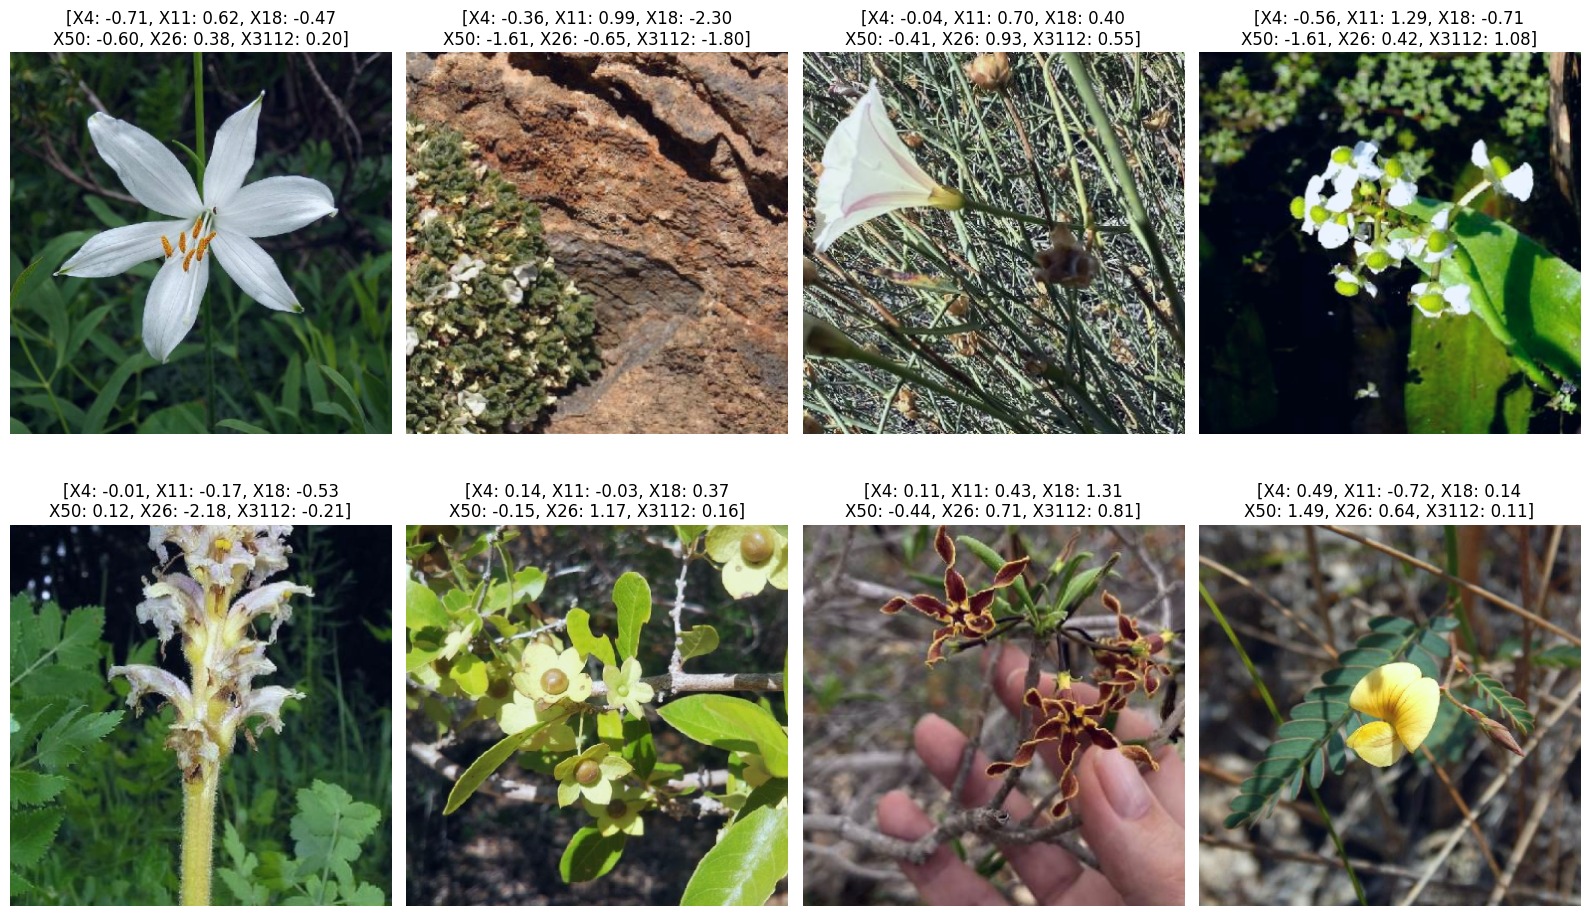

In [12]:
# Get a batch of data
inps, tars = next(iter(train_dataloader))
imgs = inps["images"]
num_imgs, num_cols = 8, 4

# Convert PyTorch tensors to NumPy arrays
imgs_np = imgs.numpy()
tars_np = tars[0].numpy()

plt.figure(figsize=(4 * num_cols, num_imgs // num_cols * 5))

for i, (img, tar) in enumerate(zip(imgs_np[:num_imgs], tars_np[:num_imgs])):
    plt.subplot(num_imgs // num_cols, num_cols, i + 1)

    # Normalize the image to [0, 1]
    img = (img - img.min()) / (img.max() - img.min() + 1e-4)

    formatted_tar = "\n".join(
        [
            ", ".join(
                f"{name.replace('_mean','')}: {val:.2f}"
                for name, val in zip(CFG.TARGET_COLUMNS[j : j + 3], tar[j : j + 3])
            )
            for j in range(0, len(CFG.TARGET_COLUMNS), 3)
        ]
    )

    plt.imshow(img.transpose(1, 2, 0))  # Transpose to (height, width, channels)
    plt.title(f"[{formatted_tar}]")
    plt.axis("off")

plt.tight_layout()
plt.show()

# <b><span style='color: #196f3d '>|</span> Model</b><a class='anchor' id='model'></a> [↑](#top) 

***
We just use a pre-trained vision transformer. Nothing fancy.

In [13]:
class ImageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
                CFG.BACKBONE,
                num_classes=6,
                pretrained=False)
        
    def forward(self, inputs):
        return self.backbone(inputs)

# <b><span style='color:#196f3d'>|</span> Inference</b><a class='anchor' id='inference'></a> [↑](#top) 

***

In [14]:
def invert_log_scale(data_array, columns, log_scale_columns):
    """Inverts the log scale on the provided columns of the input dataframe if they are also in log_scale_columns"""
    for idx, col in enumerate(columns):
        if col in log_scale_columns:
            data_array[:, idx] = np.power(10, data_array[:, idx])
    return data_array

In [15]:
# Instantiate the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ImageModel()
model.to(device)

#Load the best model
model.load_state_dict(torch.load(BEST_MODEL_PATH))

# List to store predictions
SUBMISSION_ROWS = []

# Iterate over batches in the test data loader
model.eval()
for batch_idx, (inputs_dict, test_ids) in enumerate(tqdm(test_dataloader, desc='Testing')):
    # Extract images and features from the inputs_dict
    inputs_images = inputs_dict['images'].to(device, dtype=torch.float32)  
    inputs_features = inputs_dict['tab_features'].to(device, dtype=torch.float32)

    # Forward pass them through the model
    with torch.no_grad():
        predictions = model(inputs_images).cpu().numpy()
        
    #Reverse the scaling done
    predictions = TARGET_SCALER.inverse_transform(predictions)
    
    #Reverse log-scaling
    invert_log_scale(predictions,CFG.TARGET_COLUMNS, LOG_LABELS)

    # Append predictions to the list
    SUBMISSION_ROWS.append(predictions)

# Concatenate predictions for all batches
SUBMISSION_ROWS = np.concatenate(SUBMISSION_ROWS, axis=0)

Testing:   0%|          | 0/655 [00:00<?, ?it/s]

# <b><span style='color:#196f3d'>|</span> Submission</b><a class='anchor' id='submission'></a> [↑](#top) 

***

In [16]:
submission_df = test_df[["id"]].copy()
target_cols = [x.replace("_mean","") for x in CFG.TARGET_COLUMNS]
submission_df[target_cols] = SUBMISSION_ROWS.tolist()

submission_df.to_csv('submission.csv', index=False)
print("Submitted!")
submission_df

Submitted!


,id,X4,X11,X18,X50,X26,X3112
0,201238668,0.542231,9.873996,1.266665,1.375810,0.298948,266.446075
1,202310319,0.553251,18.875374,0.349023,1.012230,0.059655,1070.474976
2,202604412,0.629397,14.735529,1.645229,1.590581,10.135278,506.477905
3,201353439,0.491306,18.790859,0.159802,1.279019,1.063243,1117.221069
4,195351745,0.522320,11.703920,0.306539,1.499985,0.754302,207.901672
...,...,...,...,...,...,...,...
6540,195548469,0.573127,9.651231,1.264314,2.146772,2.372663,260.575958
6541,199261251,0.504257,16.987537,3.429955,1.154985,21.686211,3692.762207
6542,203031744,0.408507,27.232077,0.321569,1.257666,1.881515,2980.112549
6543,197736382,0.498166,19.019667,0.147298,1.281547,0.385932,270.094604
